<a href="https://colab.research.google.com/github/meghakamath527-jpg/assignment-01-bitsom_ba_2511041/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install sentence-transformers


In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 10 sentences across 3 topics

sentences = [
    # Cricket
    "Cricket is a game played with a bat and a ball between two teams of eleven players.",
    "I have never played cricket.",
    "I have seen one person throw the ball, 1 person hit the ball and the rest running behind the ball, they call it cricket.",
    "Street cricket is common in India.",

    # Cooking
    "I hate cooking.",
    "Cooking requires you to stand and get cooked in the kitches along with the ingredients.",
    "Cooking is not just a womens job anymore.",

    # Cybersecurity
    "I keep getting cybersecurity lessons at work.",
    "Strong passwords help protect user accounts.",
    "Encryption ensures secure data transmission"
]


In [11]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


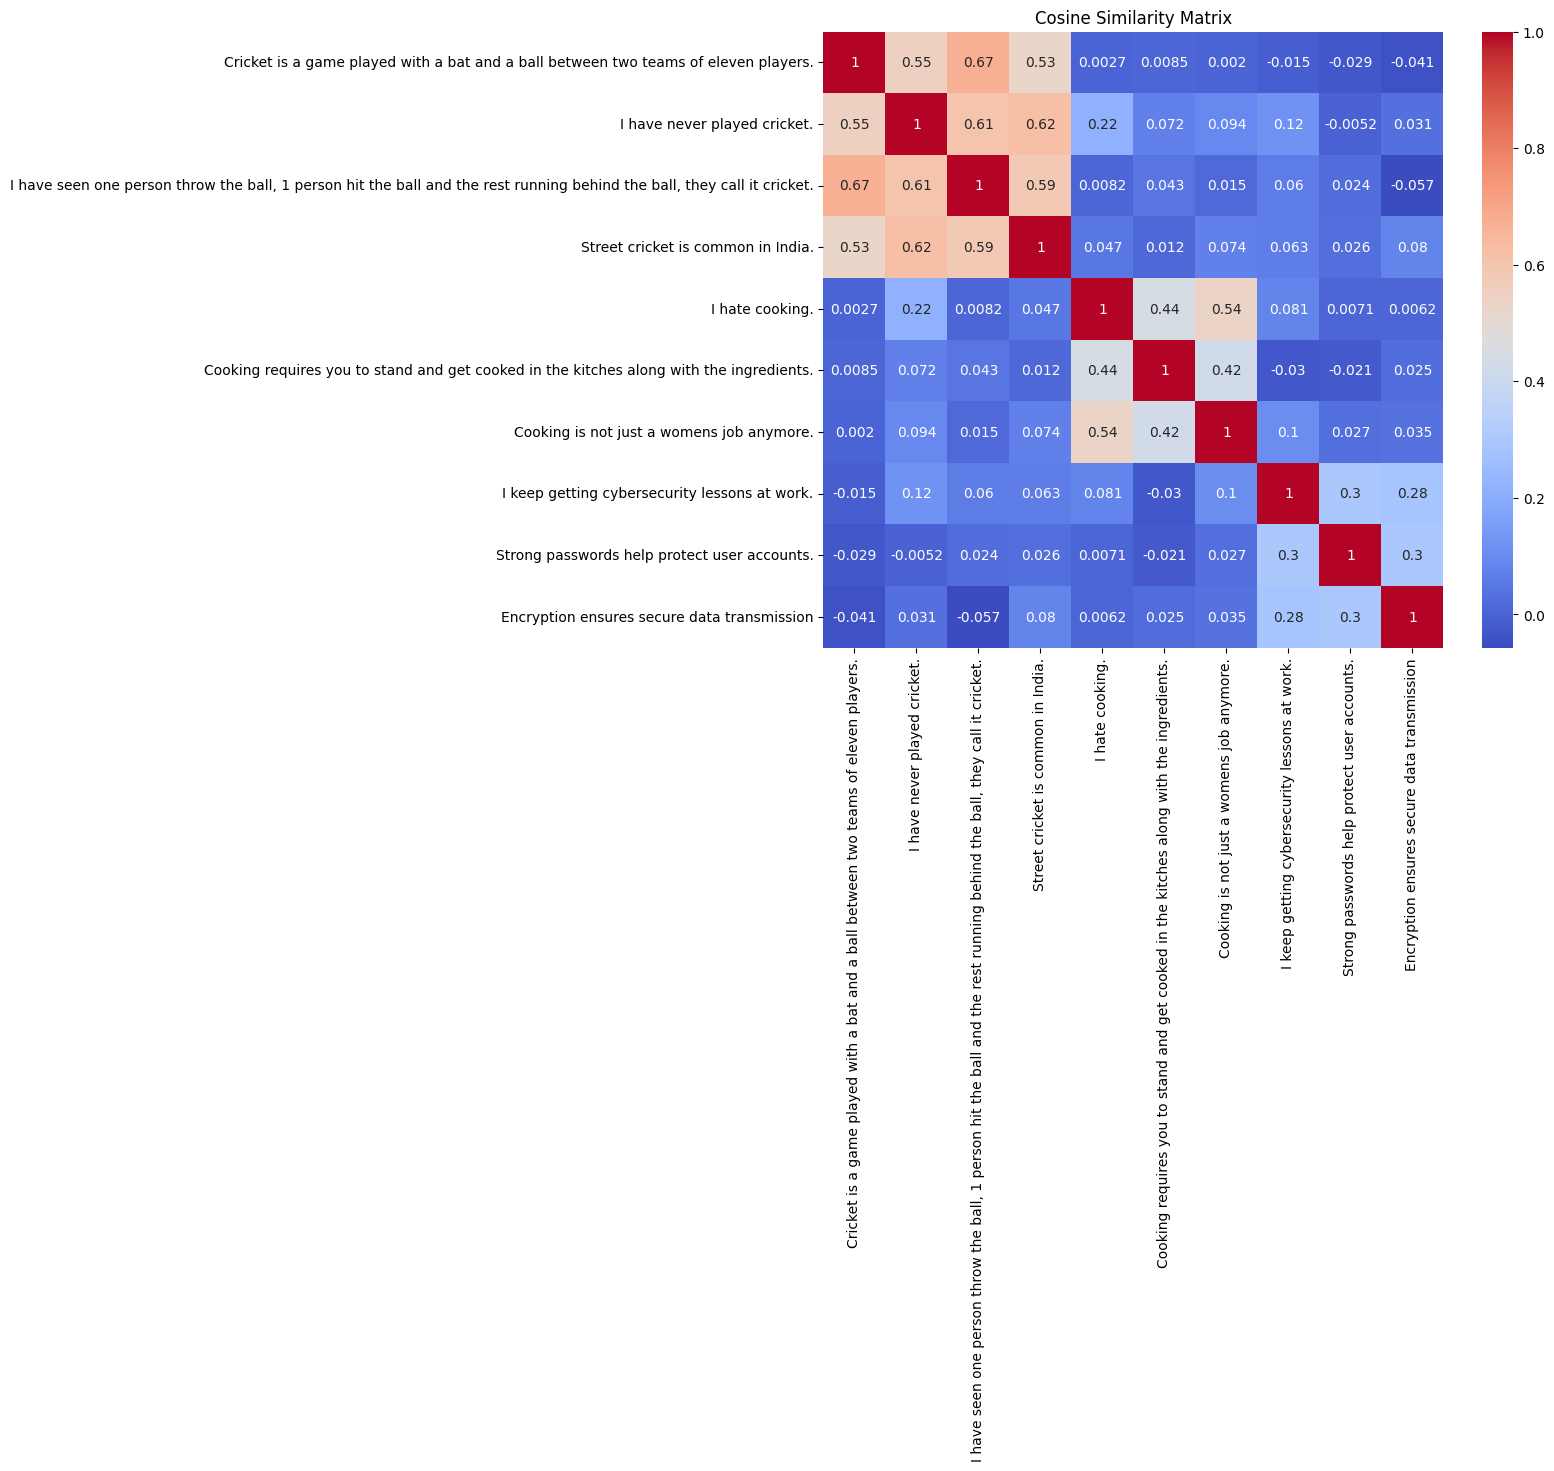

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

# Convert to DataFrame for better display
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

plt.figure(figsize=(10,8))
sns.heatmap(df, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()


In [10]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")


Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: I have seen one person throw the ball, 1 person hit the ball and the rest running behind the ball, they call it cricket.
Similarity Score: 0.4503

Sentence: Cricket is a game played with a bat and a ball between two teams of eleven players.
Similarity Score: 0.4110

